## Customize Neural Network Models with Keras

This notebook explores different ways to build neural network models using Keras in TensorFlow. We will cover three primary methods: Sequential API, Functional API, and Model Subclassing. Each method offers varying levels of flexibility and control over the model's architecture, suitable for different types of problems and complexity levels.

In [53]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [54]:
# We simulate a simple classification task:
# Each sample has 20 numerical features
# Goal: predict one of 3 classes

num_samples = 1500
num_features = 20
num_classes = 3

# Input data: random Gaussian features
# Think of this as raw "observations"
x = np.random.normal(size=(num_samples, num_features)).astype("float32")

# Hidden "true relationship" (like a real-world unknown function)
true_w = np.random.normal(size=(num_features, num_classes)).astype("float32")

# We generate logits using a linear transformation + noise
# This simulates a realistic imperfect dataset
logits = x @ true_w + 0.25 * np.random.normal(size=(num_samples, num_classes))

# Convert logits → class labels
# This becomes our supervised learning target
y = np.argmax(logits, axis=1).astype("int32")

# Train / validation split
x_train, x_val = x[:1200], x[1200:]
y_train, y_val = y[:1200], y[1200:]

print("x_train.shape:", x_train.shape)
print("y_train.shape:", y_train.shape)
print("x_val.shape:", x_val.shape)
print("y_val.shape:", y_val.shape)

x_train.shape: (1200, 20)
y_train.shape: (1200,)
x_val.shape: (300, 20)
y_val.shape: (300,)


In [55]:
ticket_samples = 1200

# Three independent feature groups
# Each represents a different "view" of a ticket

title_data = np.random.randint(0, 2, size=(ticket_samples, 100)).astype("float32")
body_data = np.random.randint(0, 2, size=(ticket_samples, 1000)).astype("float32")
tags_data = np.random.randint(0, 2, size=(ticket_samples, 12)).astype("float32")

print("title_data.shape:", title_data.shape)
print("body_data.shape:", body_data.shape)
print("tags_data.shape:", tags_data.shape)

title_data.shape: (1200, 100)
body_data.shape: (1200, 1000)
tags_data.shape: (1200, 12)


In [56]:
priority_targets = (0.4 * title_data[:, :10].mean(axis=1)
+ 0.4 * body_data[:, :30].mean(axis=1)
    + 0.2 * tags_data[:, :4].mean(axis=1)
    + 0.05 * np.random.normal(size=(ticket_samples,)))

priority_targets = np.clip(priority_targets, 0, 1).astype("float32").reshape(-1, 1)
print(priority_targets[:10])

[[0.51210475]
 [0.45776558]
 [0.6369543 ]
 [0.50732094]
 [0.32378104]
 [0.35961545]
 [0.52517045]
 [0.3005516 ]
 [0.5233708 ]
 [0.4372313 ]]


In [57]:
department_scores = np.stack([title_data[:, :25].mean(axis=1),
                              body_data[:, :250].mean(axis=1),
                              body_data[:, 250:500].mean(axis=1),
                              tags_data[:, :4].mean(axis=1),], axis=1)

# Choose highest scoring department
department_targets = np.argmax(department_scores, axis=1).astype("int32")
print(department_targets[:20])

[3 1 3 3 1 0 0 0 3 1 1 3 0 3 3 0 1 3 3 0]


In [58]:
split = 900

ticket_train_inputs = {"title": title_data[:split],
                       "body": body_data[:split],
                       "tags": tags_data[:split],}

ticket_val_inputs = {"title": title_data[split:],
                     "body": body_data[split:],
                     "tags": tags_data[split:],}

ticket_train_targets = {"priority": priority_targets[:split],
                        "department": department_targets[:split],}

ticket_val_targets = {"priority": priority_targets[split:],
                      "department": department_targets[split:],}

print("Keys of ticket_train_inputs:", ticket_train_inputs.keys())
print("Keys of ticket_train_targets:", ticket_train_targets.keys())
print("Keys of ticket_val_inputs:", ticket_val_inputs.keys())
print("Keys of ticket_val_targets:", ticket_val_targets.keys())

Keys of ticket_train_inputs: dict_keys(['title', 'body', 'tags'])
Keys of ticket_train_targets: dict_keys(['priority', 'department'])
Keys of ticket_val_inputs: dict_keys(['title', 'body', 'tags'])
Keys of ticket_val_targets: dict_keys(['priority', 'department'])


In [59]:
def build_sequential_model():

    # A Sequential model is just a pipeline: Input → Hidden Layers → Output
    inputs = keras.Input(shape=(num_features,), name="features")

    hidden_layer1 = layers.Dense(64, activation="relu")(inputs) # Hidden representation learning
    hidden_layer2 = layers.Dense(32, activation="relu")(hidden_layer1) # Non-linear feature extraction

    # Output layer converts features → probabilities
    outputs = layers.Dense(num_classes, activation="softmax")(hidden_layer2)

    model = keras.Model(inputs=inputs, outputs=outputs, name="sequential_classifier")

    return model

In [60]:
seq_model = build_sequential_model()
seq_model.summary()

Model: "sequential_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,523 (13.76 KB)

 Trainable params: 3,523 (13.76 KB)

 Non-trainable params: 0 (0.00 B)

### Sequential Model

Keras Sequential API is the simplest way to build a model. It's a linear stack of layers where you just add layers one after another. It's suitable for simple models where the output of one layer is the input to the next, without any branching, multiple inputs, or multiple outputs.

In [61]:
seq_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", # Sparse categorical crossentropy because labels are integers
                  metrics=["accuracy"])

history_seq = seq_model.fit(x_train, y_train, validation_data=(x_val, y_val),
                            epochs=5, batch_size=32)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4725 - loss: 1.0340 - val_accuracy: 0.5300 - val_loss: 0.9371
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6875 - loss: 0.7945 - val_accuracy: 0.7233 - val_loss: 0.7156
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8133 - loss: 0.5649 - val_accuracy: 0.8400 - val_loss: 0.5055
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8850 - loss: 0.3925 - val_accuracy: 0.8667 - val_loss: 0.3782
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9150 - loss: 0.2872 - val_accuracy: 0.9033 - val_loss: 0.3027


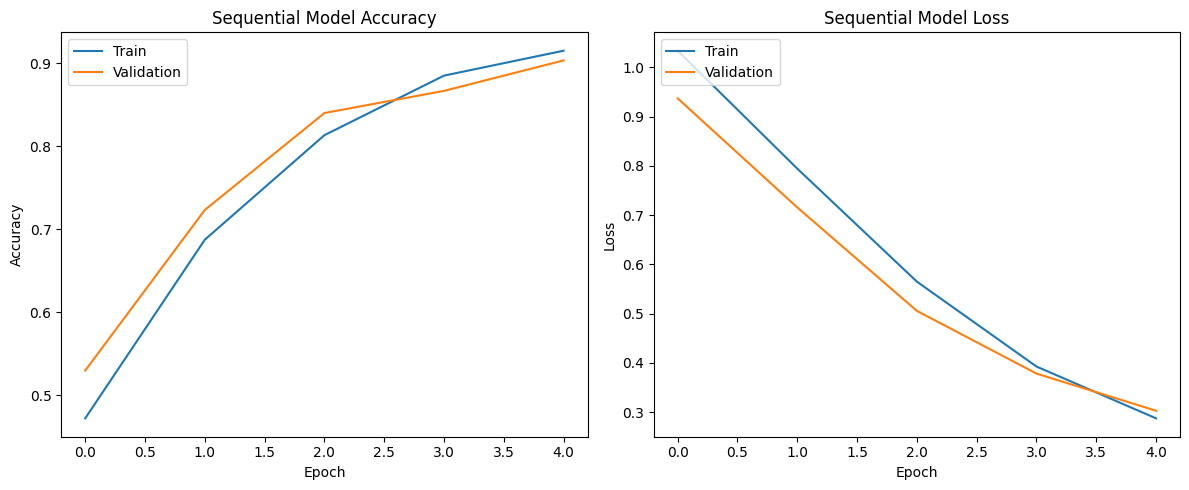

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_seq.history['accuracy'])
plt.plot(history_seq.history['val_accuracy'])
plt.title('Sequential Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_seq.history['loss'])
plt.plot(history_seq.history['val_loss'])
plt.title('Sequential Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [63]:
def build_functional_model():

    # Each input represents a different information source
    title_input = keras.Input(shape=(100,), name="title")
    body_input = keras.Input(shape=(1000,), name="body")
    tags_input = keras.Input(shape=(12,), name="tags")

    '''
    title_input = keras.Input(shape=(100,), name="title")
    -> This creates a symbolic KerasTensor with shape (batch_size, 100). It's a placeholder, not actual data.

    When `title_features = layers.Dense(64, activation="relu", name="title_features")(title_input)` is called:
    Keras uses the symbolic `title_input` (shape: (None, 100)) to infer the input shape for the `Dense` layer.
    The `Dense` layer then automatically creates its weights, for example, a weight matrix of shape (100, 64) for this transformation.

    '''

    # Each branch learns its own representation: (100,) → (64,)
    title_features = layers.Dense(64, activation="relu", name="title_features")(title_input)
    body_features = layers.Dense(64, activation="relu", name="body_features")(body_input)

    # Merge all information sources into one representation
    # Since title_features: (64,); body_features: (64,); tags_input: (12,)
    # Concatenation: 64 + 64 + 12 = 140
    x = layers.Concatenate(name="concat_features")([title_features,
                                                    body_features, tags_input])
    # Print the shape
    print("x.shape:", x.shape)

    # Shared representation layer
    shared = layers.Dense(64, activation="relu", name="shared_features")(x)

    # Output 1: regression (priority score)
    priority_output = layers.Dense(1, activation="sigmoid", name="priority")(shared)

    # Output 2: classification (department)
    department_output = layers.Dense(4, activation="softmax", name="department")(shared)

    return keras.Model(inputs=[title_input, body_input, tags_input],
                       outputs=[priority_output, department_output], name="ticket_model")

build_functional_model()

x.shape: (None, 140)


<Functional name=ticket_model, built=True>

### Functional Model

The Keras Functional API is a more flexible way to build models. It allows you to define models that have non-linear topology, shared layers, and multiple inputs or outputs. This is achieved by connecting layers like building blocks, where you explicitly define the input(s) and output(s) of the model. Each layer takes a tensor as input and returns a tensor as output.

In [64]:
functional_model = build_functional_model()
functional_model.summary()

x.shape: (None, 140)


Model: "ticket_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ body (InputLayer)   │ (None, 1000)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ title_features      │ (None, 64)        │      6,464 │ title[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ body_features       │ (None, 64)        │     64,064 │ body[0][0]        │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tags (InputLayer)   │ (None, 12)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_features     │ (None, 140)       │          0 │ title_features[0… │
│ (Concatenate)       │                   │            │ body_features[0]… │
│                     │                   │            │ tags[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_features     │ (None, 64)        │      9,024 │ concat_features[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ priority (Dense)    │ (None, 1)         │         65 │ shared_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ department (Dense)  │ (None, 4)         │        260 │ shared_features[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 79,877 (312.02 KB)

 Trainable params: 79,877 (312.02 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
functional_model.compile(optimizer="rmsprop",
                         # Each output has its own loss function
                         loss={"priority": "mse", "department":
                               "sparse_categorical_crossentropy" },

                         # Metrics per task
                         metrics={"priority": ["mae"],
                                  "department": ["accuracy"]})

history_ticket = functional_model.fit(ticket_train_inputs,
                                      ticket_train_targets,
                                      validation_data=(ticket_val_inputs,
                                                       ticket_val_targets),
                                      epochs=3, batch_size=32)

Epoch 1/3
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - department_accuracy: 0.3767 - department_loss: 1.3679 - loss: 1.3824 - priority_loss: 0.0186 - priority_mae: 0.1098 - val_department_accuracy: 0.3300 - val_department_loss: 1.4401 - val_loss: 1.4688 - val_priority_loss: 0.0342 - val_priority_mae: 0.1547
Epoch 2/3
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - department_accuracy: 0.4867 - department_loss: 1.1864 - loss: 1.2085 - priority_loss: 0.0174 - priority_mae: 0.1062 - val_department_accuracy: 0.4533 - val_department_loss: 1.2410 - val_loss: 1.2582 - val_priority_loss: 0.0176 - val_priority_mae: 0.1082
Epoch 3/3
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - department_accuracy: 0.6000 - department_loss: 1.0523 - loss: 1.0722 - priority_loss: 0.0169 - priority_mae: 0.1043 - val_department_accuracy: 0.4067 - val_department_loss: 1.3392 - val_loss: 1.3662 - val_priority_loss: 0.0184 - val_priority_mae: 0.1081


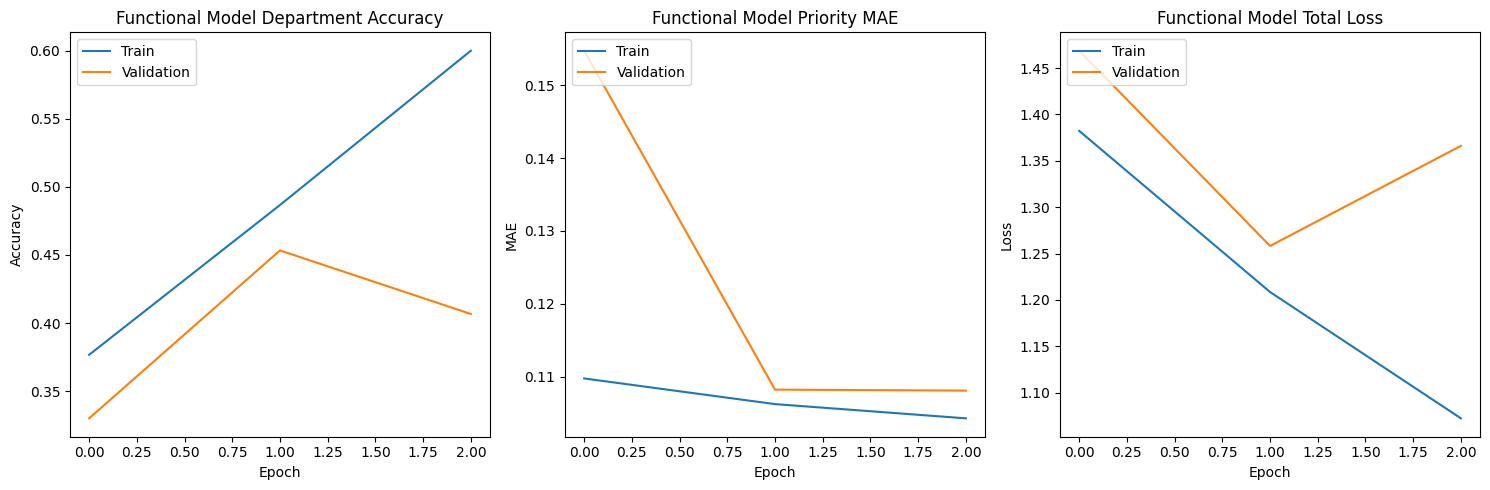

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Plot training & validation accuracy values for 'department'
plt.subplot(1, 3, 1)
plt.plot(history_ticket.history['department_accuracy'])
plt.plot(history_ticket.history['val_department_accuracy'])
plt.title('Functional Model Department Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation MAE values for 'priority'
plt.subplot(1, 3, 2)
plt.plot(history_ticket.history['priority_mae'])
plt.plot(history_ticket.history['val_priority_mae'])
plt.title('Functional Model Priority MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 3, 3)
plt.plot(history_ticket.history['loss'])
plt.plot(history_ticket.history['val_loss'])
plt.title('Functional Model Total Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [67]:
# This model exposes internal representation learning
# Useful for visualization or transfer learning

feature_extractor = keras.Model(inputs=functional_model.inputs,
    outputs=functional_model.get_layer("shared_features").output,
                                name="feature_extractor")

sample_features = feature_extractor.predict({k: v[:3] for k, v
                                             in ticket_val_inputs.items()})

print(sample_features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
(3, 64)


In [68]:
def build_siamese_model():

    input_a = keras.Input(shape=(10,), name="item_a")
    input_b = keras.Input(shape=(10,), name="item_b")

    # Shared encoder = same weights applied to both inputs
    shared_encoder = layers.Dense(16, activation="relu", name="shared_encoder")

    encoded_a = shared_encoder(input_a)
    encoded_b = shared_encoder(input_b)

    print("encoded_a.shape:", encoded_a.shape)
    print("encoded_b.shape:", encoded_b.shape)

    # Cosine similarity measures angle between vectors
    similarity = layers.Dot(axes=1, normalize=True, name="cosine_similarity")([encoded_a, encoded_b])

    return keras.Model([input_a, input_b], similarity), shared_encoder

In [69]:
siamese_model, _ = build_siamese_model()
siamese_model.summary()

# Generate some dummy data for training
num_siamese_samples = 1000
item_a_train = np.random.normal(size=(num_siamese_samples, 10)).astype("float32")
item_b_train = np.random.normal(size=(num_siamese_samples, 10)).astype("float32")

# Create dummy similarity targets (e.g., if item_a and item_b are similar, similarity is high)
# For simplicity, let's say similarity is higher if their dot product is higher
similarity_train = np.sum(item_a_train * item_b_train, axis=1).astype("float32")

# Normalize similarity_train to be between 0 and 1, as the output layer is sigmoid
similarity_train = (similarity_train - similarity_train.min()) / (similarity_train.max() - similarity_train.min())
similarity_train = similarity_train.reshape(-1, 1)

# Compile the siamese model
siamese_model.compile(optimizer="adam", loss="mse")

# Train the siamese model
history_siamese = siamese_model.fit([item_a_train, item_b_train],
                                    similarity_train, epochs=5, batch_size=32,
                                    validation_split=0.2)

encoded_a.shape: (None, 16)
encoded_b.shape: (None, 16)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ item_a (InputLayer) │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_b (InputLayer) │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_encoder      │ (None, 16)        │        176 │ item_a[0][0],     │
│ (Dense)             │                   │            │ item_b[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cosine_similarity   │ (None, 1)         │          0 │ shared_encoder[0… │
│ (Dot)               │                   │            │ shared_encoder[1… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 176 (704.00 B)

 Trainable params: 176 (704.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0359 - val_loss: 0.0376
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0328 - val_loss: 0.0354
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0301 - val_loss: 0.0332
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0277 - val_loss: 0.0312
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0255 - val_loss: 0.0293


### Subclassing Model

Model subclassing is a highly flexible way to build Keras models by inheriting from `tf.keras.Model`. In this approach, you define your model as a Python class, create layers as attributes in the constructor (`__init__`), and define the model's forward pass in the `call` method. This gives you full control over the model's architecture and behavior, allowing for custom layers, arbitrary control flow, and easy integration with custom training loops.

In [70]:
class MLPClassifier(keras.Model):

    def __init__(self, num_classes=3):
        super().__init__(name="subclassed_mlp")

        # Explicit layer definitions
        self.dense1 = layers.Dense(64, activation="relu")
        self.dropout = layers.Dropout(0.3)
        self.dense2 = layers.Dense(32, activation="relu")
        self.out = layers.Dense(num_classes, activation="softmax")

    def call(self, inputs, training=False):
        # Forward pass is fully controlled here
        x = self.dense1(inputs)
        # Dropout behaves differently during training vs inference
        x = self.dropout(x, training=training)
        x = self.dense2(x)

        return self.out(x)

In [71]:
sub_model = MLPClassifier(num_classes=num_classes)

# Build model (required for summary)
_ = sub_model(tf.zeros((1, num_features)))

sub_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

history_sub = sub_model.fit(x_train, y_train,
                            validation_data=(x_val, y_val),
                            epochs=5, batch_size=32)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4967 - loss: 1.0122 - val_accuracy: 0.6733 - val_loss: 0.8389
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6525 - loss: 0.8103 - val_accuracy: 0.7933 - val_loss: 0.6558
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7400 - loss: 0.6550 - val_accuracy: 0.8600 - val_loss: 0.5098
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7775 - loss: 0.5445 - val_accuracy: 0.8733 - val_loss: 0.4053
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8142 - loss: 0.4458 - val_accuracy: 0.8900 - val_loss: 0.3298


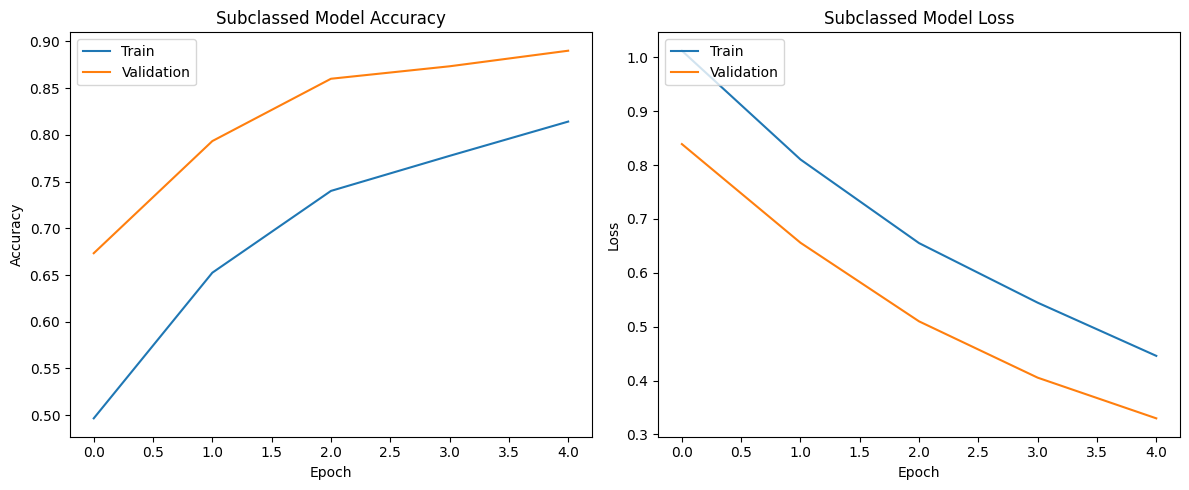

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_sub.history['accuracy'])
plt.plot(history_sub.history['val_accuracy'])
plt.title('Subclassed Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_sub.history['loss'])
plt.plot(history_sub.history['val_loss'])
plt.title('Subclassed Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()